In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, Qubit, Gate
from qiskit.quantum_info import Statevector, Operator

from itertools import chain
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import time

import timeit
import random

# Subset Sum - Building Blocks

## The Adder

In [2]:
#First a useful Debugging tool
def test_circuit(n_qubits, bits):
    q_reg = QuantumRegister(size=n_qubits)
    circ = QuantumCircuit(q_reg)
    for i in bits:
        circ.x(q_reg[i])
    return circ

In [3]:
# Implemented based on https://arxiv.org/pdf/quant-ph/0410184
def unmajority_circuit(quantum_circuit, cpa, bpa, c):
    r'''
    $c_i$ The ith carry bit
    $b_i$ the ith bit of b
    $a_i$ the ith bit of a

    $c_i \oplus a_i \to c_i$
    $b_i \oplus a_i \oplus s_i$
    $c_{i+1} \to a_i$    
    '''
    quantum_circuit.ccx(cpa, bpa, c)
    quantum_circuit.cx(c, cpa)
    quantum_circuit.cx(cpa, bpa)

# Majority
def maj_circuit():
    r'''
    .. math::
        $c_i$ The ith carry bit
        $b_i$ the ith bit of b
        $a_i$ the ith bit of a

        $c_i \to c_i \oplus a_i$
        $b_i \to b_i \oplus a_i$
        $a_i \to c_{i+1}$    
    '''
    c_reg = QuantumRegister(size=1, name=r"c_i")
    b_reg = QuantumRegister(size=1, name=r"b_i")
    a_reg = QuantumRegister(size=1, name=r"a_i")
    maj = QuantumCircuit(c_reg, b_reg, a_reg, name=r"MAJ")
    maj.cx(a_reg[0], b_reg[0])
    maj.cx(a_reg[0], c_reg[0])
    maj.ccx(c_reg[0], b_reg[0], a_reg[0])
    return maj

# Unmajority and add
def uma_circuit(circuit=False):
    r'''
    $c_i$ The ith carry bit
    $b_i$ the ith bit of b
    $a_i$ the ith bit of a

    $c_i \oplus a_i \to c_i$
    $b_i \oplus a_i \oplus s_i$
    $c_{i+1} \to a_i$    
    '''
    cpa_reg = QuantumRegister(size=1, name=r"c_i \oplus a")
    cpb_reg = QuantumRegister(size=1, name=r"c_i \oplus b")
    c_reg = QuantumRegister(size=1, name=r"c_\{i+1\}")

    uma = QuantumCircuit(cpa_reg, cpb_reg, c_reg, name="UMA")
    uma.ccx(cpa_reg[0], cpb_reg[0], c_reg[0])
    uma.cx(c_reg[0], cpa_reg[0])
    uma.cx(cpa_reg[0], cpb_reg[0])
    return uma

    
def ripple_carry_adder(n_qubits:int, overflow=True):
    rf'''
    A Quantum circuit that adds a to b (both n_qubits in length)

    |ab> -> |as> where s is the sum of a and b

    if overflow is set to True, we instead get
    |abz> -> |asz> where z is the overflow bit

    input wires:
    -
    - a -
    -

    -
    - b -
    -

    - c -
    '''
    ripple_carry_add = QuantumCircuit(name="RCA")
    a_reg = QuantumRegister(size=n_qubits, name="a")
    b_reg = QuantumRegister(size=n_qubits, name="b")
    c_reg = AncillaRegister(size=1, name="carry_in")
    if overflow:
        z_reg = AncillaRegister(size=1, name="carry_out")
        ripple_carry_add.add_register(a_reg, b_reg, c_reg, z_reg)
    else:
        ripple_carry_add.add_register(a_reg, b_reg, c_reg)

    maj = maj_circuit().to_gate()
    uma = uma_circuit().to_gate()
    ripple_carry_add.compose(maj, qubits=[c_reg, b_reg[0], a_reg[0]],inplace=True)
    for i in range(1,n_qubits):
        ripple_carry_add.compose(maj, qubits=[a_reg[i-1], b_reg[i], a_reg[i]], inplace=True)
    if overflow:
        ripple_carry_add.cx(a_reg[n_qubits-1], z_reg[0])
    for i in range(n_qubits - 1 ,0, -1):
        ripple_carry_add.compose(uma, qubits=[a_reg[i-1], b_reg[i], a_reg[i]], inplace=True)
    ripple_carry_add.compose(uma, qubits=[c_reg, b_reg[0], a_reg[0]], inplace=True) 
    return ripple_carry_add

Now We visualize the adder

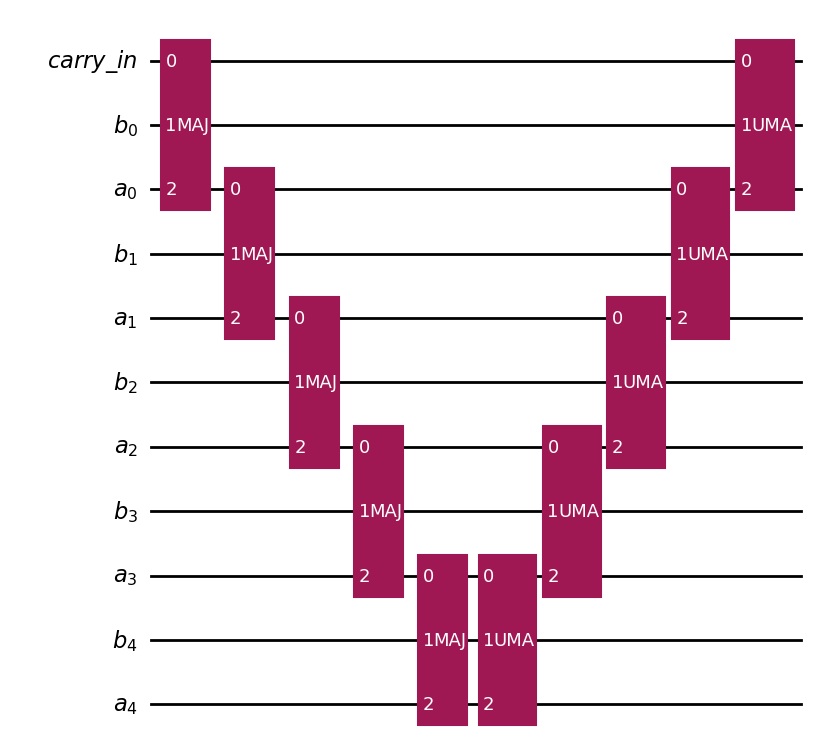

In [4]:
n = 5
overflow=False
rc_5 = ripple_carry_adder(5, overflow=overflow)

# We want to alternate the wires to clearly show how the gates are arranged
carry_reg = [2*n] # Ancilla carry in bit
alternating_regs = list(chain(*zip(range(n, 2*n),range(n)))) # Alternating (b_i, a_i)
overflow_reg = ([2*n +1] if overflow else []) # Overflow bit
alternate_wire_order = carry_reg + alternating_regs + overflow_reg

rc_5.draw(output='mpl', wire_order=alternate_wire_order)

## The MCZ Circuit

In [5]:
def mcz_circuit(n_qubits):
    r"""
    A multi-controlled z gate implemented using only Hadamard, cnot, not, and Tofelli gates

    input wires:
    - 
    - ancilla register -
    -

    -
    - input -
    -

    - c (should be |0>)

    n_quibtis is the number of quibits in the mcz gate
    """

    # If we do not have enough qubits for a mcz circuit, do nothing
    if n_qubits <= 1:
        return QuantumCircuit(n_qubits*2 + 1, name="MCZ")
    
    mcz = QuantumCircuit(name="MCZ")
    a_reg = QuantumRegister(size=n_qubits-1, name="a")
    b_reg = QuantumRegister(size=n_qubits, name="b")
    c_reg = AncillaRegister(size=1, name="carry_in")
    
    mcz.add_register(a_reg, b_reg, c_reg)
    maj = maj_circuit().to_gate()
    maj_dag = maj.inverse()
    
    # Carry in a 1
    mcz.x(c_reg[0])
    mcz.compose(maj, qubits=[c_reg, b_reg[0], a_reg[0]],inplace=True)
    for i in range(1,n_qubits-1):
        mcz.compose(maj, qubits=[a_reg[i-1], b_reg[i], a_reg[i]], inplace=True)
    # If we overflowed most significant qubit we negate the final qubit 
    #mcz.barrier()
    mcz.h(b_reg[n_qubits-1])
    mcz.cx(a_reg[n_qubits-2], b_reg[n_qubits-1])
    mcz.h(b_reg[n_qubits-1])
    #mcz.barrier()
    # Uncompute
    for i in range(n_qubits - 2 ,0, -1):
        mcz.compose(maj_dag, qubits=[a_reg[i-1], b_reg[i], a_reg[i]], inplace=True)
    mcz.compose(maj_dag, qubits=[c_reg, b_reg[0], a_reg[0]], inplace=True) 
    mcz.x(c_reg[0])
    return mcz
    

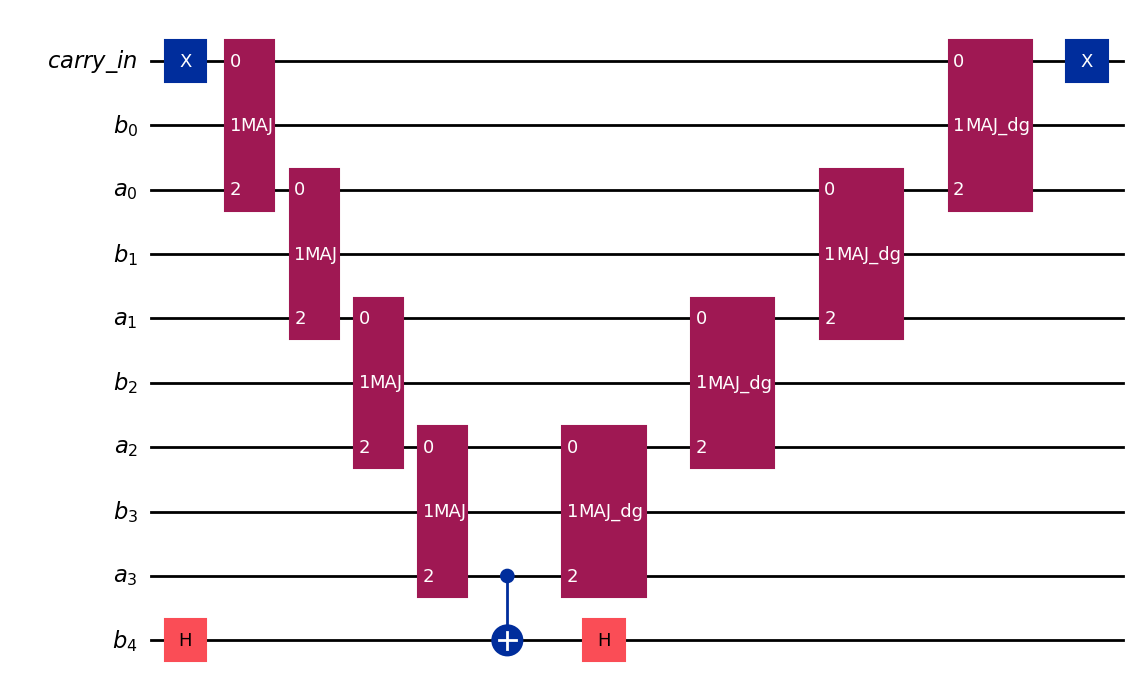

In [6]:
n = 5

# We want to alternate the wires to clearly show how the gates are arranged
carry_reg = [2*n-1] # Ancilla carry in bit
alternating_regs = list(chain(*zip(range(n-1, 2*(n-1)),range(n)))) # Alternating (b_i, a_i)
alternate_wire_order = carry_reg[:] + alternating_regs[:-1] + [n-2] + [2*(n-1)]
mcz_circuit(n_qubits=5).draw(output='mpl', wire_order=alternate_wire_order)

## Building our weighted Adder

In [7]:
def controlled_add_circuit(n_qubits, val):
    """
    A controlled adder gate. 

    input wires:
    - Control - 

    -
    - ancilla registers - 
    -

    -
    - running sum registers -
    - 

    - Carry bit register (for the adder, presumably |0>) -
    

    n_qubits is the number of quibits for the running sum
    val is the value we are adding to the running sum
    """
    x_reg = QuantumRegister(size=1, name='x')
    sum_regs = QuantumRegister(size=n_qubits, name='s')
    anc_regs = AncillaRegister(size=n_qubits, name='a')
    c_reg = AncillaRegister(size=1, name='c')
    controlled_add = QuantumCircuit(
        x_reg, 
        anc_regs, 
        sum_regs, 
        c_reg, 
        name=f"Controlled Add {val}")

    # Twos-Complement representation of the value 
    twos_complement = val if val >= 0 else 2**n_qubits + val
    bit_string = f'{int(twos_complement):>0{n_qubits}b}'
    
    rca = ripple_carry_adder(n_qubits, overflow=False).to_gate()

    # Set the value if x_i is 1
    for i, bit in enumerate(bit_string[::-1]):
        if bit == "1":
            controlled_add.cx(x_reg[0], anc_regs[i])    

    # Add the input to the sum
    controlled_add.compose(rca, qubits=controlled_add.qubits[1:], inplace=True)

    # Reset the input
    for i, bit in enumerate(bit_string[::-1]):
        if bit == "1":
            controlled_add.cx(x_reg[0], anc_regs[i])

    return controlled_add
    

def weighted_sum_circuit(n_qubits, vals):
    """
    Computes the "weighted sum" (a sum of values (each adder is controlled by a control bit (i.e. the weight))
    input wires:
    -
    - Control registers - 
    -

    -
    - ancilla registers - 
    -

    -
    - running sum registers -
    - 

    - c (|0>) -

    n_qubits is the number of quibits for the running sum
    vals is the list of values we are adding to the running sum (controled by corresponding control bits
    """
    n_x_vals = len(vals)
    x_regs = QuantumRegister(size=n_x_vals, name='x')
    s_regs = QuantumRegister(size=n_qubits, name='s')
    anc_regs = AncillaRegister(size=n_qubits, name='a')
    c_reg = AncillaRegister(size=1, name='c')

    weighted_sum = QuantumCircuit(
        x_regs,
        anc_regs,
        s_regs,
        c_reg,
        name=f"WS {vals}")

    for i, val in enumerate(vals):
        controlled_adder = controlled_add_circuit(n_qubits, val).to_gate()
        weighted_sum.compose(controlled_adder, [x_regs[i]] + weighted_sum.qubits[n_x_vals:], inplace=True)
    return weighted_sum



    


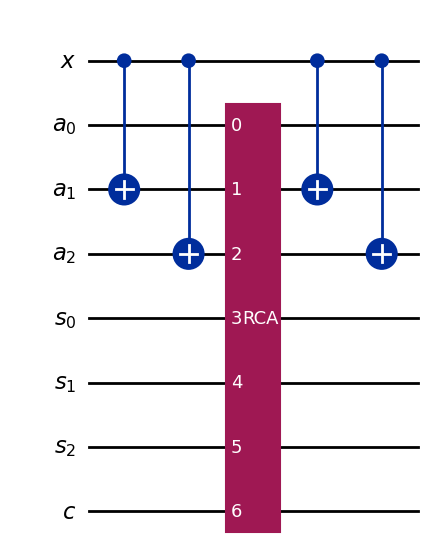

In [8]:
controlled_add_circuit(n_qubits=3, val=-2).draw(output='mpl')

In [9]:
test = test_circuit(8, [0])
test.compose(controlled_add_circuit(n_qubits=3, val=-2).to_gate(), inplace=True)

print(test)
psi = Statevector(test)
psi.draw(output='latex')

      ┌───┐┌────────────────────┐
q0_0: ┤ X ├┤0                   ├
      └───┘│                    │
q0_1: ─────┤1                   ├
           │                    │
q0_2: ─────┤2                   ├
           │                    │
q0_3: ─────┤3                   ├
           │  Controlled Add -2 │
q0_4: ─────┤4                   ├
           │                    │
q0_5: ─────┤5                   ├
           │                    │
q0_6: ─────┤6                   ├
           │                    │
q0_7: ─────┤7                   ├
           └────────────────────┘


<IPython.core.display.Latex object>

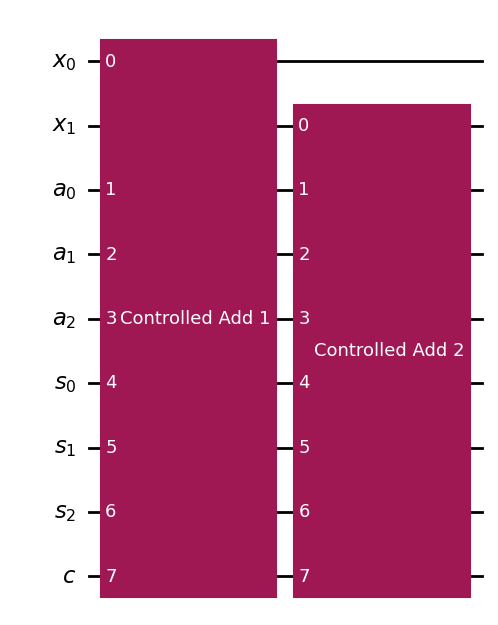

In [18]:
weighted_sum_circuit(n_qubits=3, vals = [1,2]).draw(output='mpl')

## Now onto the Grover oracle and diffuser

In [10]:
def subsetsum_oracle_circuit(n_qubits, vals, target):
    """
    Computes (weighted sum, reflection about the target vale, uncompute wighted sum)
    
    input wires:
    -
    - Control registers - 
    -

    -
    - ancilla registers - 
    -

    -
    - running sum registers (also ancilla) -
    - 

    - c (|0>) -

    n_qubits is the number of quibits for the running sum
    vals is the list of values we are adding to the running sum (controled by corresponding control bits
    target is the target for the sum
    """

    n_x_vals = len(vals)
    x_regs = QuantumRegister(size=n_x_vals, name='x')
    s_regs = AncillaRegister(size=n_qubits, name='s')
    anc_regs = AncillaRegister(size=n_qubits, name='a')
    c_reg = AncillaRegister(size=1, name='c')

    subsetsum_oracle = QuantumCircuit(
        x_regs,
        anc_regs,
        s_regs,
        c_reg,
        name="SubsetSum Oracle")

    twos_complement = target if target >= 0 else 2**n_qubits + target
    bit_string = f'{int(twos_complement):>0{n_qubits}b}'
    
    weighted_sum = weighted_sum_circuit(n_qubits, vals).to_gate()
    weighted_sum_dag = weighted_sum.inverse()
    mcz = mcz_circuit(n_qubits).to_gate()

    subsetsum_oracle.compose(weighted_sum, inplace=True)
    # Set the value if x_i is 1
    for i, bit in enumerate(bit_string[::-1]):
        if bit == "0":
            subsetsum_oracle.x(s_regs[i]) 
    subsetsum_oracle.compose(mcz, qubits=(anc_regs[0:n_qubits-1] + s_regs[:] + c_reg[:]), inplace=True)
    for i, bit in enumerate(bit_string[::-1]):
        if bit == "0":
            subsetsum_oracle.x(s_regs[i])
    subsetsum_oracle.compose(weighted_sum_dag, inplace=True)
    
    return subsetsum_oracle


def grover_diffuser_circuit(n_vals):
    """
    Diffuser circuit for Grovers algorithm
    
    input wires:
    -
    - Control registers - 
    -

    -
    - ancilla registers - 
    -

    - c (|0>) -

    n_vals is the number of control bits
    """
    
    x_regs = QuantumRegister(size=n_vals, name='x')
    anc_regs = AncillaRegister(size=n_vals-1, name='a')
    c_reg = AncillaRegister(size=1, name='c')
    diffuser = QuantumCircuit(x_regs, anc_regs, c_reg, name="Diffuser")

    mcz = mcz_circuit(n_vals).to_gate()
    
    # Hadamard then Not gates
    diffuser.h(x_regs)
    diffuser.x(x_regs)
    # Multi-controlled z gate
    diffuser.compose(mcz, qubits=(anc_regs[:] + x_regs[:] + c_reg[:]), inplace=True)
    # Not gates then Haddamard gates
    diffuser.x(x_regs)
    diffuser.h(x_regs)

    return diffuser

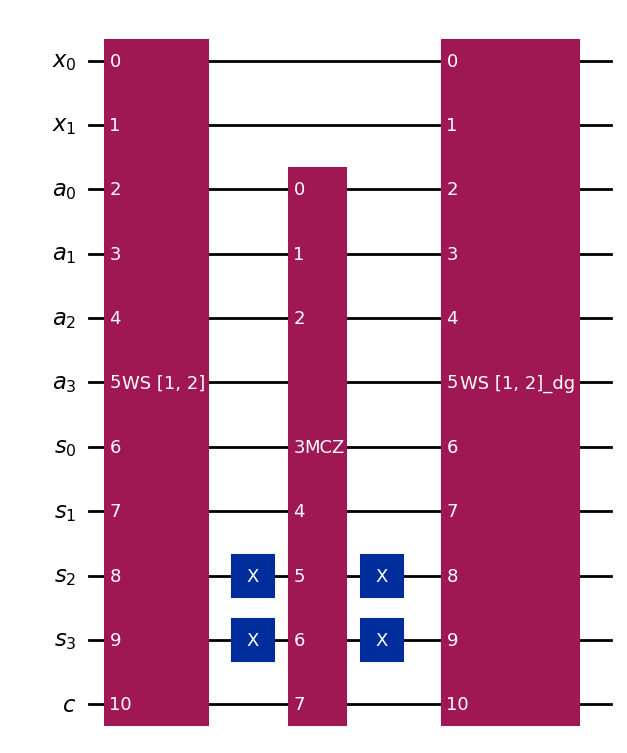

In [12]:
subsetsum_oracle_circuit(4, [1,2], 3).draw(output='mpl')

## Finishing the Circuit

In [13]:
def prep_circuit(n_vals:int):
    """
    Prepares the control bits into |++...+>
    i.e. 
    
    -- H --
    -- H --
    .
    .
    .
    -- H --

    n_vals is the number of control bits
    """
    quantum_register = QuantumRegister(size=n_vals, name='x')
    prep = QuantumCircuit(quantum_register, name="State Prep")
    prep.h(quantum_register)
    return prep

def grover_subsetsum_circuit(vals, target, n_iter=1):
    """
    Full Circuit for the subset sum problem using grovers algorithm
    """
    n_qubits = int(
        np.ceil(
            max(
                np.log2(sum(np.abs(vals))),
                np.log2(np.abs(target))
            )
        ) + 1
    )
    n_vals = len(vals)
    n_ancilla = max(2*n_qubits, n_vals) + 1

    x_regs = QuantumRegister(size=n_vals, name='x')
    anc_regs = AncillaRegister(size=n_ancilla, name='a')

    prep = prep_circuit(n_vals).to_gate()
    oracle = subsetsum_oracle_circuit(n_qubits, vals, target).to_gate()
    diffuser = grover_diffuser_circuit(n_vals).to_gate()

    grover_subsetsum = QuantumCircuit(
        x_regs,
        anc_regs,
        name=f"Grover SubsetSum")

    grover_subsetsum.compose(prep, x_regs[:], inplace=True)
    for _ in range(n_iter):
        grover_subsetsum.compose(oracle, qubits=(x_regs[:] + anc_regs[:2*n_qubits+1]), inplace=True)
        grover_subsetsum.compose(diffuser, qubits=(x_regs[:] + anc_regs[:n_vals]), inplace=True)
    return grover_subsetsum

And testing

In [14]:
# Testing 
vals = [1,2,8,-2]
target = 6
n = len(vals)
N = 2**n

K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))

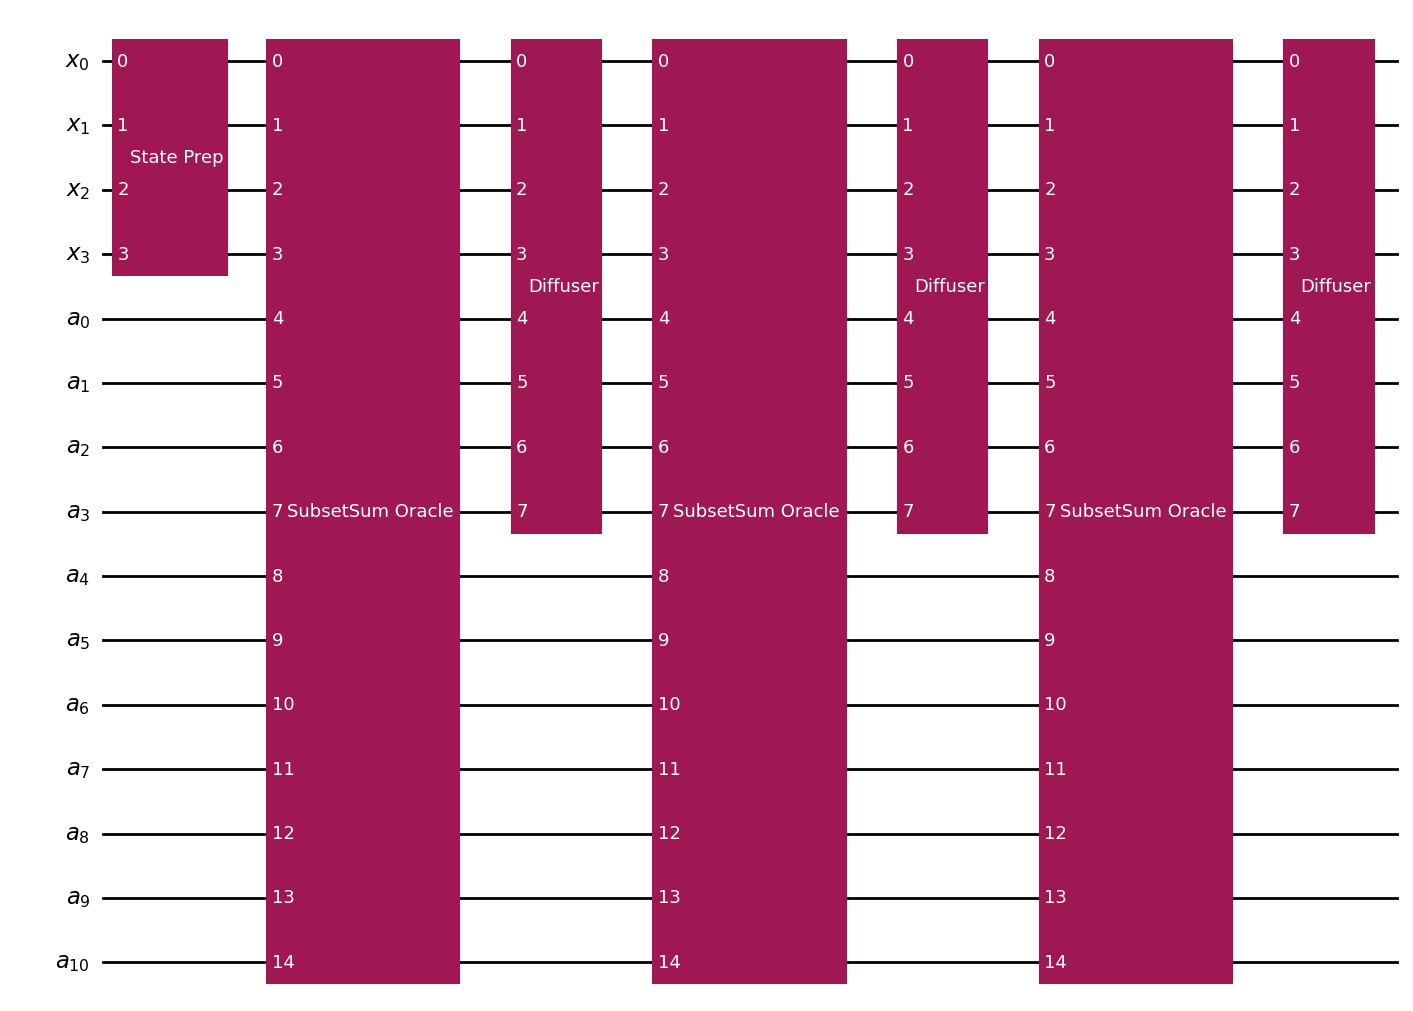

In [15]:
gsc = grover_subsetsum_circuit(vals=vals, target=target, n_iter=K)
gsc.draw(output='mpl')

# Now To run the solver

In [16]:
def num_to_indices(n:int):
    """Helper function that converts a number into indices into the subset
    based on its binary representation
    """
    bit_string = f'{int(n):b}'[::-1]
    indices = []
    for j, bit in enumerate(bit_string):
        if bit == "1": indices.append(j)
    return indices
    

def run_grover_subset(val_set: List[int], target: int, verbose:int=1, plot_probs:bool=False, savefile=None):
    """Run the grover search algorithm on the subset sum problem
    
    :param val_set: The set we want to use for the subset sum problem
    :type val_set: List of integers
    
    :param target: The target value for the sum
    :type target: int
    
    :param verbose: How verbose we want this function to be
    :type verbose: int
    
    :param plot_probs: If True, then a plot of the output probabilities will be drawn
    :type plot_probs: bool

    ...

    :return: candidates (tuple of indices into the value set) and corresponding probabilitis
    :rtype: dict
    """
    # Size of the subset
    n = len(val_set)
    # Number of subsets (i.e. size of P(val_set))
    N = 2**n
    # Number of iterations Grover's algorithm requires
    K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))

    # Evenly distributed if no solution (we double this proability to establish an arbitrary threshold for found solutions
    threshold = min(2/N, 0.5) 
    
    # Create Grover Search circuit
    start_time = time.time()
    gsc = grover_subsetsum_circuit(vals=val_set, target=target, n_iter=K)
    build_time = time.time() - start_time
    if verbose > 1:
        print(gsc)
    
    # Compute the output on |00...0>
    start_time = time.time()
    psi = Statevector(gsc)
    compute_time = time.time() - start_time

    # Evaluate Probabilities
    # List of probablities arraged by bit string (i.e. index 5, 00101 indicates that the 0th index and 3rd index are used in the corresping sum) 
    probabilities = np.round(psi.probabilities(), 3)[0:2**n]
    subset_probs = {}
    for idx, prob in enumerate(probabilities):
        indices = num_to_indices(idx)
        subset_probs[tuple(indices)] = float(prob)
    candidates = {subset: subset_probs[subset] for subset in subset_probs if subset_probs[subset] > threshold}

    # Plot the probabilites
    if plot_probs:
        plt.plot(np.arange(N), probabilities)
        for i in range(N):
            subset = [val_set[idx] for idx in num_to_indices(i)]
            if sum(subset) == target:
                plt.axvline(x=i, color='red', linestyle='--')
                plt.text(i, probabilities[i], subset, color='red')
        plt.xlabel(r"subset index")
        plt.ylabel(f"probabilities")
        plt.title(f"Prabability distribution of Grover Subset Sum\nwith {val_set} and target {target}")
        if savefile:
            plt.savefig(savefile)

    # Compute the candidates for subset sum solutions and print them if desired
    if not candidates and verbose:
        print(f"No candidates found for a subset of {val_set} to sum to {target}.")
    else:
        for candidate in candidates:
            candidate_vals = [val_set[i] for i in candidate]
            if verbose:
                print(f"Candidate {candidate_vals} sum to {sum(candidate_vals)} and the target is {target}. p = {subset_probs[candidate]:02f}")
    
    # Print timing information if sufficiently verbose
    if verbose > 1:
        print(f"Circuit build time {build_time}s")
        print(f"Circuit evaluation time {compute_time}s")
    return candidates
                


Candidate [8, -2] sum to 6 and the target is 6. p = 0.961000


{(2, 3): 0.961}

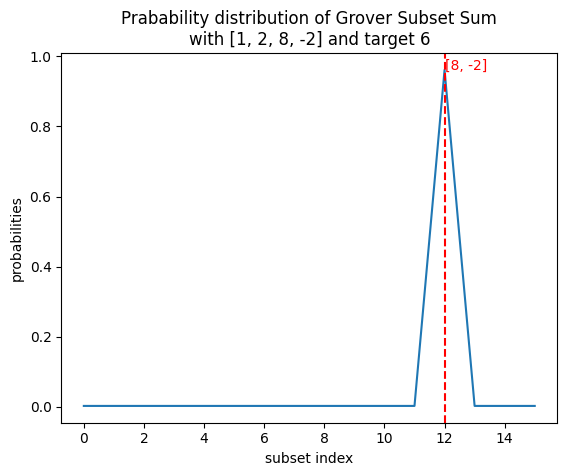

In [17]:
run_grover_subset(val_set= [1,2,8,-2], target = 6, plot_probs=True, savefile="4val.png")